# Neural Networks for Classification

Suppose we have $k$ classes, $(1,2,\ldots,k)$

goal: To predict class probabilities $P_1,P_2,\ldots,P_k$

The flow will be:

input -> neural network layers -> output layer (k neurons) -> softmax -> loss

Where the softmax function is $P_i = \frac{e^{\hat{y}_i}}{\sum_{t=1}^ke^{\hat{y}_t}}$

and the loss function (categorical cross entropy) is
$$
\sum_{i=1}^k Y_i\log P_i
$$

with $Y$ the one-hot encoding $Y_i=1$ if class =i and 0 otherwise, yielding $Y=[Y_1Y_2\ldots Y_k]=[0\ldots010\ldots 0]$

## Backpropogation

To do gradient descent, we need to compute some gradients- namely, of the softmax and loss functions

$$
\partial \text{loss} /\partial P = -[Y_1/P_1 | Y_2/P_2 | \ldots | Y_k/P_k]
$$

$$
\partial P / \partial \hat{y} =  \text{diag}(P_1,\ldots,P_k)-[P_1,\ldots,P_k]\times [P_1,\ldots,P_k]
$$

With $\times$ denoting the outer product.
****

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# neural network layer

class layer:
    # initialization
    def __init__(self, n_inputs,n_neurons): # self represents the instance of the class
        self.weights = 0.1*np.random.randn(n_inputs,n_neurons)# small random numbers
        self.biases = np.zeros((1,n_neurons)) #zeros
        
    def forward(self, inputs):
        
        # we need to store the outputs
        self.output = inputs.dot(self.weights)+self.biases
        
        #as well as the inputs
        self.inputs = inputs
        
    def backward(self, dinputs):
        
        self.dinputs = dinputs.dot(self.weights.T)
        self.dweights = self.inputs.T.dot(dinputs)
        self.dbiases = np.sum(dinputs, axis=0,keepdims = True)
        
        
# ReLU activation function
class ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0,inputs)
        self.inputs = inputs
        
    def backward(self,dinputs): 
        self.dinputs = dinputs.copy()
        self.dinputs[self.inputs<0]=0
        

# linear activation function

class linear:
    # f(x) = x
    def forward(self,inputs):
        self.output = inputs.flatten()
        self.inputs = inputs
        
    def backward(self, dinputs):
        self.dinputs = dinputs.copy().reshape(-1,1)
        
# softmax activation function
class softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs)
        probabilities = exp_values/np.sum(exp_values,axis=1,keepdims=True)
        self.output = probabilities
        self.input = inputs
    
    def backward(self,dinputs):
        # initialize derivative matrix
        self.dinputs = np.zeros(dinputs.shape)
        for i in range(len(dinputs)):
            proba = self.output[i]
            dinputs_row = dinputs[i]
            derivative_matrix = np.diag(proba)-proba.reshape(-1,1).dot(proba.reshape(1,-1))
            self.dinputs[i] = dinputs_row.dot(derivative_matrix)
        
        
# categorical cross entropy

class loss_cross_entropy:
    def forward(self,P,y):
        # number of data points
        n_samples = len(y)
        
        # clip P to prevent division by zero
        P_clipped = np.clip(P,1e-7,1-1e-7)
        
        # 
        pred_probabilities = P_clipped[np.arange(n_samples),y]
        
        losses = -np.log(pred_probabilities)
        return losses 
    
    def backward(self,P,y):
        # number of data points
        n_samples = len(y)
        
        # one-hot encoding matrix
        Y = np.zeros(P.shape)
        Y[np.arange(n_samples),y]=1
        
        # derivatives
        self.dinputs = -Y/P/n_samples



# loss function
class loss_mse:
    def forward(self,yhat,y):
        losses = (y-yhat)**2 # this is a vector but we need to compute the mean of its entries
        return losses
    
    def backward(self,yhat, y):
        self.dinputs = (-2/len(y))*(y-yhat)
        
#optimizer

class optimizer_GD:
    def __init__(self, learning_rate):
        self.learning_rate=learning_rate
        
    def update_parameters(self,layer):
        layer.weights = layer.weights - self.learning_rate*layer.dweights
        layer.biases = layer.biases - self.learning_rate*layer.dbiases
        

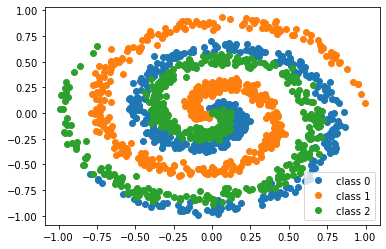

In [3]:


# generate toy dataset
classes = 3
n_points = 500
noise = 0.35
radius = 10

X = np.zeros((n_points*classes, 2))
y = np.zeros(n_points*classes).astype('int')

for class_number in range(classes):
    ix = range(n_points*class_number, n_points*(class_number+1))
    r = np.linspace(0,1, n_points)
    t = np.linspace(class_number*radius, (class_number+1)*radius, n_points) + np.random.randn(n_points)*noise
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = class_number
    
for i in range(classes):
    plt.plot(X[y==i,0],X[y==i,1],'o',label = 'class '+str(i))
plt.legend()



In [4]:
# build neural network

# layer 1
layer1 = layer(n_inputs = 2, n_neurons = 64)
activation1 = ReLU()

# layer 2
layer2 = layer(n_inputs = 64, n_neurons = 64)
activation2 = ReLU() 

# layer 3 
layer3 = layer(n_inputs = 64, n_neurons = classes)
activation3  = softmax()

# loss function 
loss_function = loss_cross_entropy()

# optimizer
optimizer = optimizer_GD(learning_rate = 1)


In [5]:
n_epochs = 2000
error = np.zeros(n_epochs)
y_pred = np.zeros(y.shape)

# gradient descent iterations
for epoch in range(n_epochs):

    # forward pass
    layer1.forward(X)
    activation1.forward(layer1.output)
    layer2.forward(activation1.output)
    activation2.forward(layer2.output)
    layer3.forward(activation2.output)
    activation3.forward(layer3.output)

    # loss (mean squared error)
    losses = loss_function.forward(activation3.output,y)


    # backward pass
    loss_function.backward(activation3.output,y)
    activation3.backward(loss_function.dinputs)
    layer3.backward(activation3.dinputs)
    activation2.backward(layer3.dinputs)
    layer2.backward(activation2.dinputs)
    activation1.backward(layer2.dinputs)
    layer1.backward(activation1.dinputs)
    
    
    # update weights and biases
    optimizer.update_parameters(layer1)
    optimizer.update_parameters(layer2)
    optimizer.update_parameters(layer3)


    
    # print loss and accuracy (every 100 epochs)
    if epoch % 100 == 0:
        # loss
        loss = np.round(np.mean(losses),3)
        # accuracy (percentage of correct classifications)
        y_pred = np.argmax(activation3.output,axis=1)
        accuracy = np.round(100*np.mean(y==y_pred),3)
        print('epoch: '+str(epoch))
        print('loss: '+str(np.round(np.mean(losses),3)))
        print('accuracy: '+str(accuracy))
        print('------------------------')

epoch: 0
loss: 1.102
accuracy: 31.667
------------------------
epoch: 100
loss: 1.063
accuracy: 42.0
------------------------
epoch: 200
loss: 1.059
accuracy: 42.867
------------------------
epoch: 300
loss: 1.048
accuracy: 44.067
------------------------
epoch: 400
loss: 1.023
accuracy: 46.733
------------------------
epoch: 500
loss: 0.91
accuracy: 58.6
------------------------
epoch: 600
loss: 1.189
accuracy: 56.267
------------------------
epoch: 700
loss: 0.832
accuracy: 56.4
------------------------
epoch: 800
loss: 0.496
accuracy: 76.267
------------------------
epoch: 900
loss: 0.447
accuracy: 75.2
------------------------
epoch: 1000
loss: 0.404
accuracy: 80.0
------------------------
epoch: 1100
loss: 0.351
accuracy: 83.8
------------------------
epoch: 1200
loss: 0.297
accuracy: 86.4
------------------------
epoch: 1300
loss: 0.278
accuracy: 87.133
------------------------
epoch: 1400
loss: 0.308
accuracy: 85.733
------------------------
epoch: 1500
loss: 0.212
accuracy: 91.

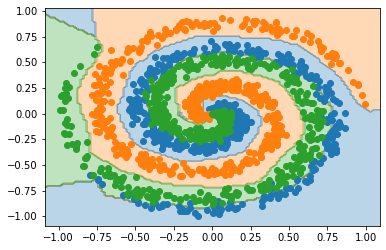

In [6]:
# plot classification regions
from matplotlib.colors import ListedColormap
# step size
h = 0.02

# mesh grid
x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
X_plot = np.c_[xx.ravel(),yy.ravel()]

# forward pass
layer1.forward(X_plot)
activation1.forward(layer1.output)
layer2.forward(activation1.output)
activation2.forward(layer2.output)
layer3.forward(activation2.output)
activation3.forward(layer3.output)


# predictions
y_pred = activation3.output
y_plot = np.argmax(y_pred, axis=1)
y_plot = y_plot.reshape(xx.shape)

# classification regions
my_cmap = ListedColormap(['C'+str(i) for i in range(classes)])
plt.contourf(xx, yy, y_plot, cmap=my_cmap, alpha=0.3)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

# dataset
for i in range(classes):
    plt.plot(X[y==i,0],X[y==i,1],'o')